### Checking if William's data matches miepython

The purpose of test_silicon_for_comparison.ipynb file is to replicate a CSV similar to silicon_σabs.csv, so that whenever it loads the data both match correctly, on this notebook the data is loaded as is and we work with the dataframes only, no nanoparticles properties are calculated in this notebook is purely to compare both programs.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both William's data and miepython's data
Wabs = pd.read_csv("silicon_σabs.csv")  # William's data
t = pd.read_csv("test.csv")             # miepython estimation

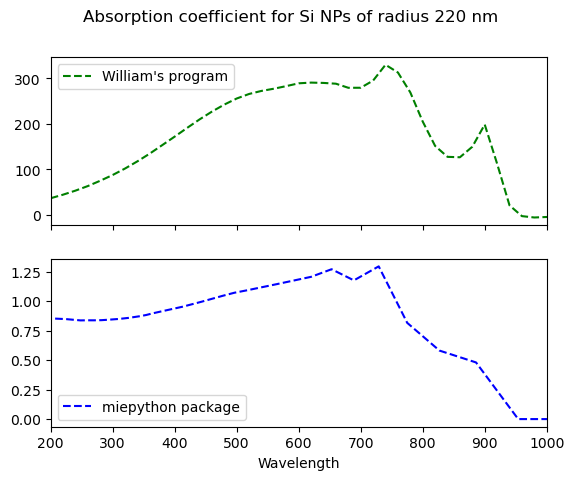

In [77]:
# Automate legend and title stuff for quick calculation and image generation
size_idx = 45                                    # Index selection, it chooses a radius of the data and compares it --- Vary this index to check how different sizes behave on both programs, max 50.
size = float(Wabs.columns[size_idx])            # gets size as float for plotting
t_cross_section = (np.pi * (size*1e-18))        # particle cross section

# Get data, divide William's data by the cross section, miepython already deals with it as efficiencies
abs_W = Wabs.iloc[:, size_idx]/t_cross_section
abs_miepython = t.iloc[:, size_idx]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, sharex = True)
fig.suptitle(f'Absorption coefficient for Si NPs of radius {round(size)} nm')
ax1.plot(Wabs.iloc[:,0], abs_W, "--g", label = "William's program")
ax2.plot(t.iloc[:,0], abs_miepython, "--b", label = "miepython package")
plt.xlabel("Wavelength")
plt.xlim(200, 1000)
ax1.legend()
ax2.legend()
plt.show()